In [2]:
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

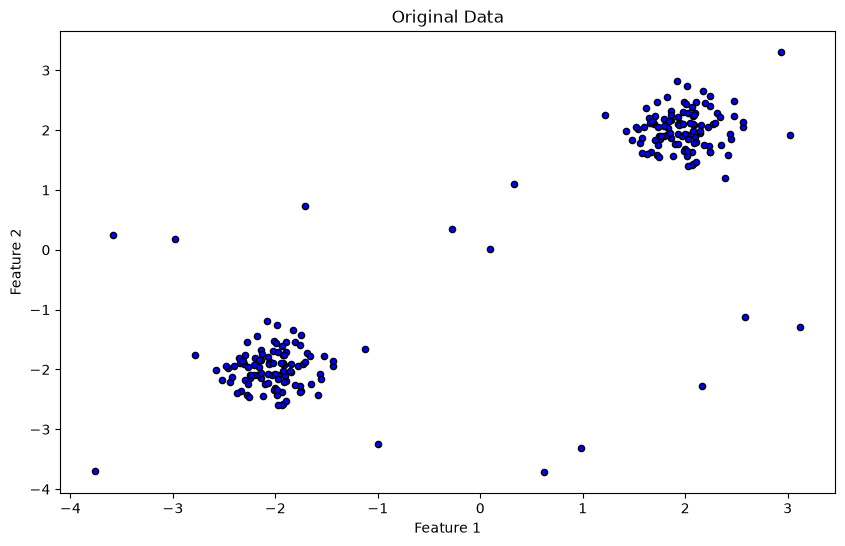

In [3]:
# Generating a sample 2D dataset
rng = np.random.RandomState(42)
X = 0.3 * rng.randn(100, 2)
X_train = np.r_[X + 2, X - 2]
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))

# Combine the datasets
X = np.r_[X_train, X_outliers]

# Plotting the dataset before outlier detection
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], color='b', s=20, edgecolor='k')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
# Fit the model
clf = IsolationForest(max_samples=100, random_state=rng, contamination='auto')
clf.fit(X)
y_pred = clf.predict(X)

In [6]:
clf.score_samples(X)

array([-0.4150876 , -0.47280663, -0.41240545, -0.4821969 , -0.40096936,
       -0.40942865, -0.46646703, -0.49206591, -0.41587151, -0.45289276,
       -0.47318204, -0.43660416, -0.40279112, -0.42581089, -0.40681209,
       -0.48796357, -0.42017964, -0.45319263, -0.46812032, -0.44344699,
       -0.42782874, -0.40897581, -0.46595917, -0.4351456 , -0.45406973,
       -0.40295997, -0.4059808 , -0.46621039, -0.41392589, -0.43034699,
       -0.4087553 , -0.45042347, -0.47579758, -0.42941338, -0.41243517,
       -0.45845622, -0.45474565, -0.55668368, -0.40510743, -0.46654577,
       -0.40291344, -0.48080457, -0.41816602, -0.43440765, -0.40468325,
       -0.4252439 , -0.41072405, -0.45317532, -0.40426194, -0.40617457,
       -0.45481543, -0.41833185, -0.40367683, -0.51204603, -0.41064612,
       -0.49503604, -0.52784811, -0.40112833, -0.42306254, -0.46558963,
       -0.44646143, -0.50412269, -0.5280767 , -0.4246619 , -0.40514328,
       -0.46842696, -0.42359279, -0.47131257, -0.4122756 , -0.45

## sklearn gives negative of anamoly score. More negative and closer to -1 then more chances of being an outlier.

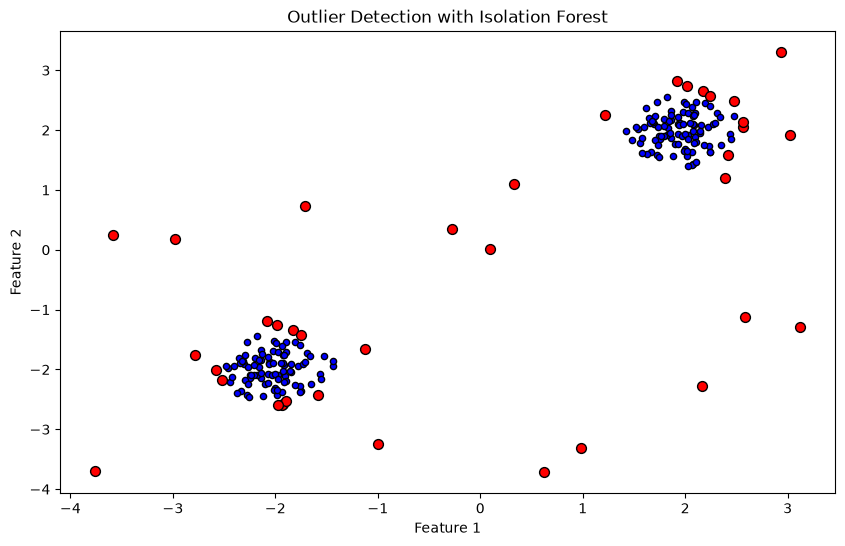

In [7]:
# Visualizing the data points and the outliers detected
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], color='b', s=20, edgecolor='k')

# Highlighting the outliers
is_outlier = y_pred == -1
plt.scatter(X[is_outlier, 0], X[is_outlier, 1], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()